<a href="https://colab.research.google.com/github/swolf3/IT480-FA26/blob/main/Assignment1_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [31]:
# Part A

In [32]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [33]:
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

quality_band
0    744
1    638
2    217
Name: count, dtype: int64


In [34]:
# The original test accuracy of this model was overfitting as the the training accuracy kept getting closer to 100 while the validation accuracy was not moving.

In [35]:
X = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y = df3["quality_band"].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

In [36]:
n_classes = len(np.unique(y))
n_features = X_train_scaled.shape[1]

In [37]:
#Part B

In [38]:
!pip install keras-tuner --quiet
import keras_tuner as kt

def build_model(hp):
  model = tf.keras.Sequential([
      tf.keras.layers.Dense(
          hp.Int("hidden1", min_value=16, max_value=128, step=16),
          activation="relu", input_shape=(n_features,)
      ),
      tf.keras.layers.Dense(
          hp.Int("hidden2", min_value=8, max_value=64, step=8),
          activation="relu"
      ),
      tf.keras.layers.Dense(n_classes, activation="softmax")
  ])
  model.compile(
      optimizer=tf.keras.optimizers.Adam(
          hp.Choice("learning_rate", values=[0.001, 0.01, 0.1])
      ),
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"]
  )
  return model

tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=5,
    overwrite=True
)

tuner.search(
    X_train_scaled, y_train,
    validation_split=0.2, epochs=50, verbose=0
)

best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'hidden1': 48, 'hidden2': 32, 'learning_rate': 0.01}


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [39]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [40]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

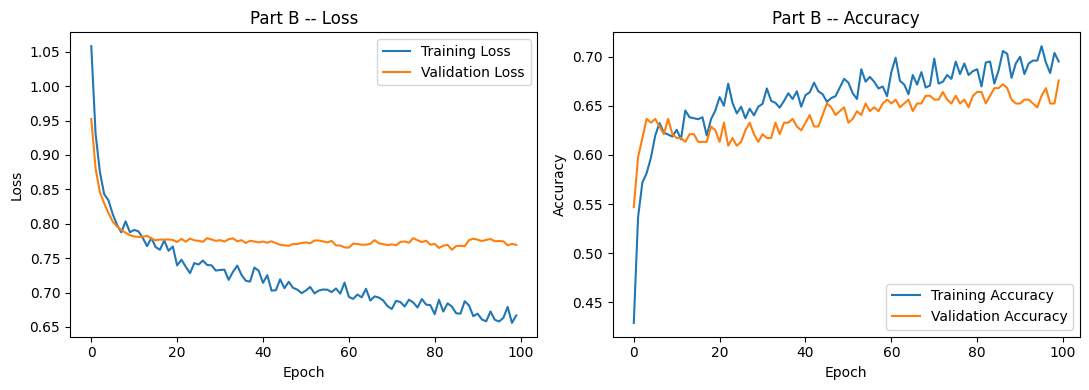

In [41]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history, "Part B", show_accuracy=True)

In [42]:
# THe graph still shows an overfitting it dude improve as opposed to the lab 1 baseline because the validation accuracy is slowly getting closer to 100 whereas in the lab 1 baseline model in was stagnant.

In [43]:
# Part C

In [44]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        64, activation="relu", input_shape=(n_features,)
    ),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

In [46]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [47]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    callbacks=[early_stop],
    verbose=0
)

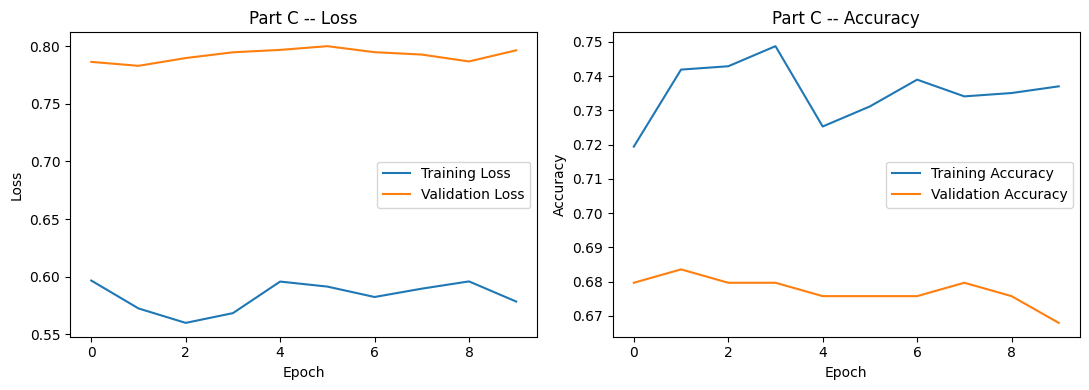

In [49]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

plot_history(history, "Part C", show_accuracy=True)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Part C -- Test Accuracy: 0.684


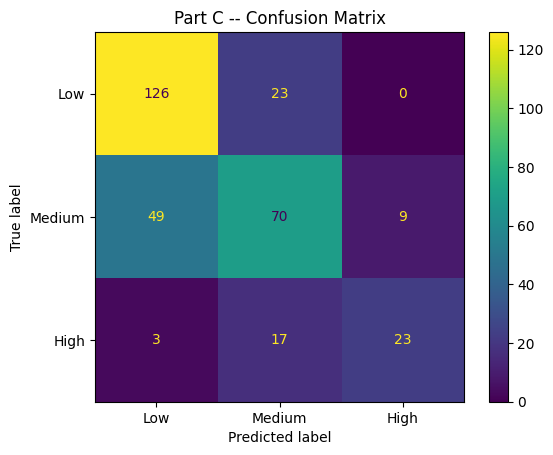

In [52]:
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)
acc_multi = accuracy_score(y_test, y_pred)
print(f"Part C -- Test Accuracy: {acc_multi:.3f}")
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    cm,
    display_labels=["Low", "Medium", "High"]
).plot()
plt.title("Part C -- Confusion Matrix")
plt.show()

In [ ]:
# The gap between training and validation loss did shrink, and was much cleaner as the early stopping stopped the model after only 10 epochs.

In [ ]:
# After applying early stopping and dropout, the test accuracy of the model came out to 0.684. The confusion matric shows errors in medium and low the most. This is a slightly better test accuracy and confusion matric as opposed to lab 1, as the accuracy in lab 1 was 0.672, and has less correct placements.

In [ ]:
# Part D

In [ ]:
# 1. It was important that the set was touched only once because the model is supposed to be ran on data that it has never ran before. If a model is only touched once it provides an accurate measure of data with no bias.

In [ ]:
# 2. If I had used the test data, the model would have bias because it has seen the data before, and therefore would be already tuned to the data.

In [ ]:
#3. It reduced the overfitting a little bit, however since it only went through 10 epochs, the validation loss looks better because the model stopped when the validation loss stopped going towards 0.

In [ ]:
# 4. If I had more time to compute, I would add more hidden layers. I think that this would help the model perform to its best.